# 04 — SHAP Explainability

Generates SHAP (SHapley Additive exPlanations) values for the SMOTE-balanced XGBoost model to provide global and local interpretability — a core requirement of the thesis's explainable early-warning system.

**Input:** `models/xgb_smote.json`, `data/test_processed.csv`

**Output:** SHAP plots saved to `outputs/` (bar, beeswarm, dependence, waterfall)

**Package versions assumed:** shap==0.44.1, xgboost==1.7.6

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

TARGET_COL = "at_risk"
os.makedirs("outputs", exist_ok=True)

shap.initjs()

Matplotlib is building the font cache; this may take a moment.
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## 1. Load model and test data

In [2]:
model = xgb.XGBClassifier()
model.load_model("models/xgb_smote.json")

test_df = pd.read_csv("data/test_processed.csv")
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

print("X_test shape:", X_test.shape)

X_test shape: (70, 35)


## 2. Compute SHAP values

`shap.TreeExplainer` is used for exact, efficient Shapley value computation for tree-based models. The resulting `Explanation` object holds per-feature, per-sample attributions.

In [3]:
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)

print("SHAP values shape:", shap_explanation.values.shape)
print("Base value (expected value):", explainer.expected_value)

SHAP values shape: (70, 35)
Base value (expected value): -0.0008609465


## 3. Global feature importance — bar plot

Mean absolute SHAP value per feature, ranked. This directly answers the thesis question: *which onboarding/engagement/SDT factors most drive the model's at-risk predictions, on average?*

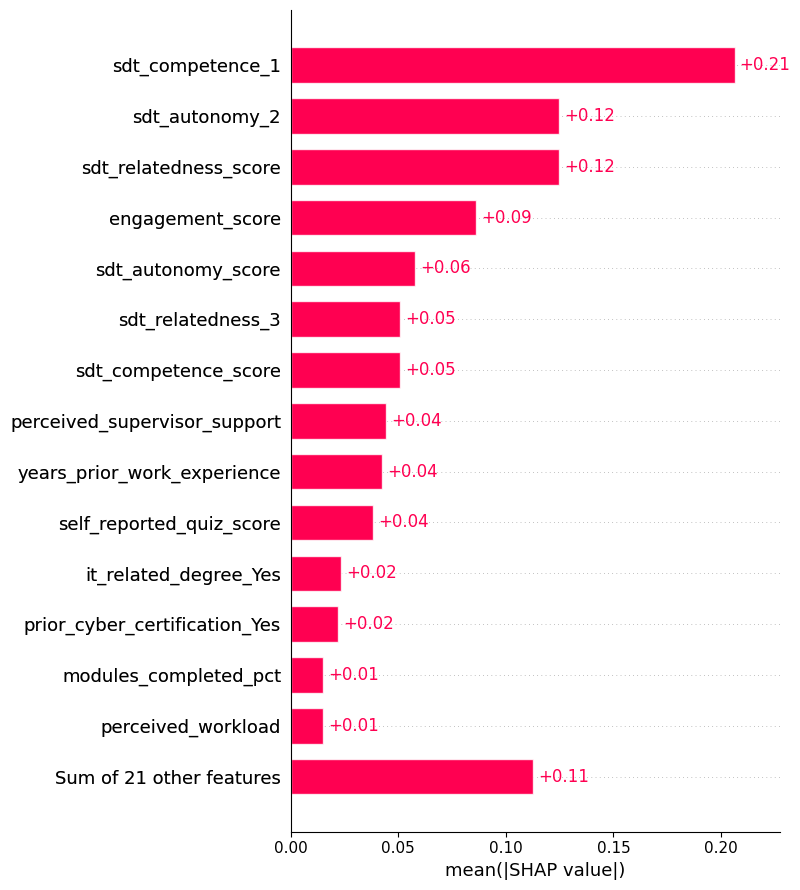

In [4]:
plt.figure()
shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_bar_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Global feature impact — beeswarm plot

Shows both the magnitude and direction of each feature's effect across all test samples (e.g., does lower `sdt_competence_score` push predictions toward 'at-risk'?).

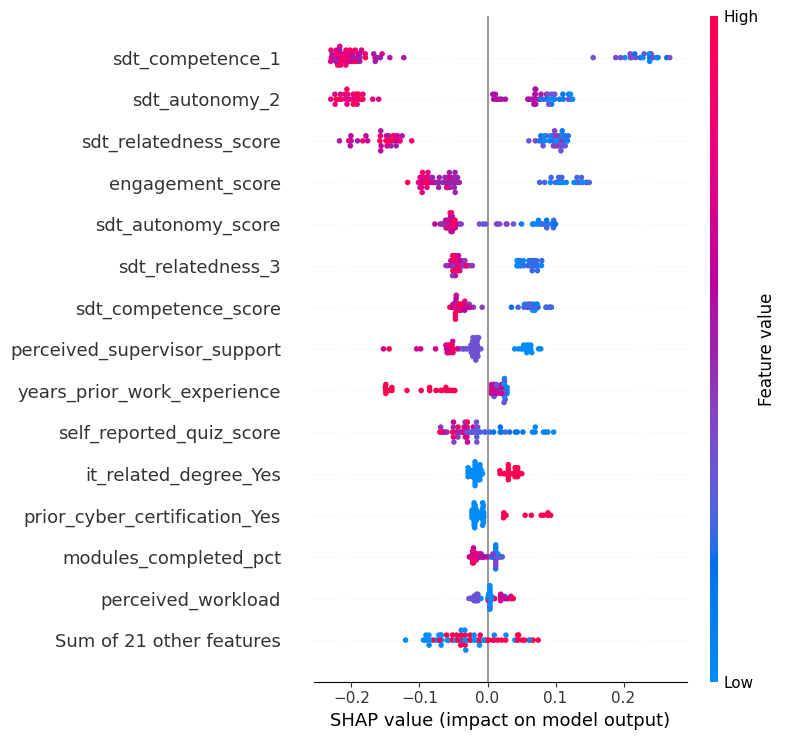

In [5]:
plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Dependence plot for the top feature

Illustrates how predictions change across the range of values for the single most important feature.

Top feature by mean |SHAP|: sdt_competence_1


<Figure size 640x480 with 0 Axes>

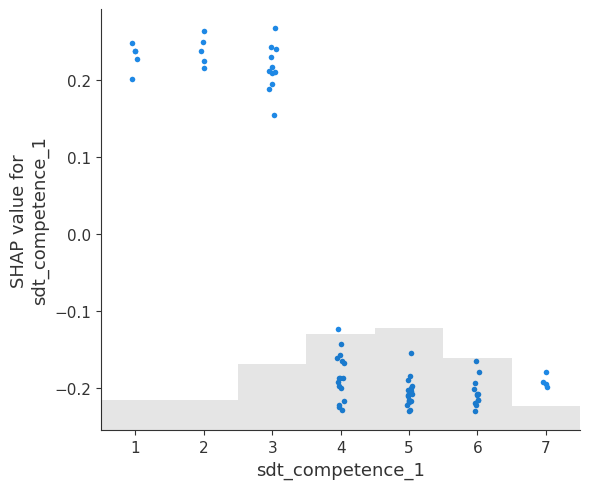

In [6]:
mean_abs_shap = np.abs(shap_explanation.values).mean(axis=0)
top_feature_idx = int(np.argmax(mean_abs_shap))
top_feature_name = X_test.columns[top_feature_idx]
print("Top feature by mean |SHAP|:", top_feature_name)

plt.figure()
shap.plots.scatter(shap_explanation[:, top_feature_name], show=False)
plt.tight_layout()
plt.savefig(f"outputs/shap_dependence_{top_feature_name}.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Local explanation — waterfall plot for a single trainee

Demonstrates the *individual-level* explainability that supports early-warning interventions: for a given graduate trainee, which factors contributed most to their risk score?

Actual label: 1 | Predicted proba: 0.55618274


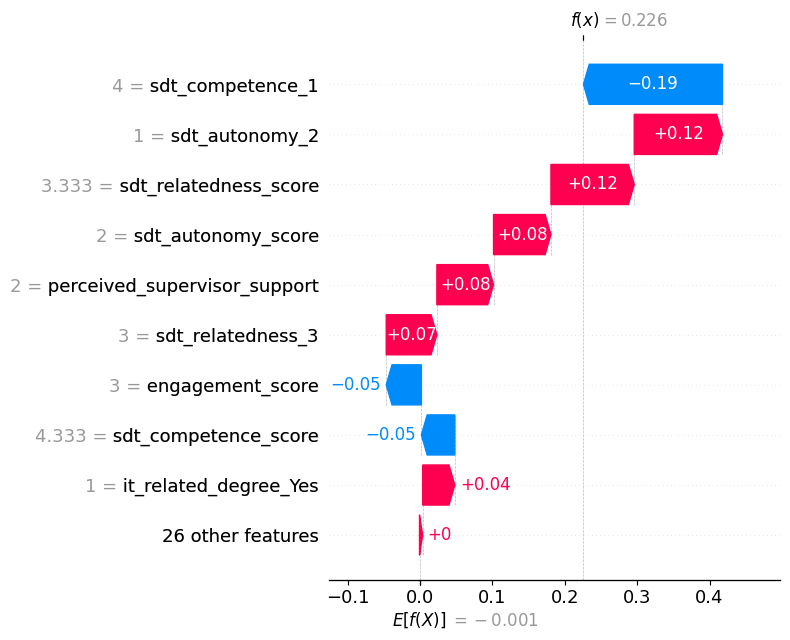

In [7]:
sample_idx = 0  # change to inspect a different test-set instance
print("Actual label:", y_test.iloc[sample_idx], "| Predicted proba:",
      model.predict_proba(X_test.iloc[[sample_idx]])[0, 1])

plt.figure()
shap.plots.waterfall(shap_explanation[sample_idx], show=False)
plt.tight_layout()
plt.savefig(f"outputs/shap_waterfall_sample{sample_idx}.png", dpi=150, bbox_inches="tight")
plt.show()

## Smoke test checklist
- [ ] `TreeExplainer` computes SHAP values without errors
- [ ] Bar, beeswarm, dependence, and waterfall plots render and save to `outputs/`
- [ ] Top feature(s) are plausible given the dummy data's known correlation structure (SDT scores, engagement, attendance should rank highly)

Proceed to **05_evaluation.ipynb**.